<a href="https://colab.research.google.com/github/carolshayle/Python/blob/main/Locality_Voronoi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. INSTALL NECESSARY LIBRARIES
!pip install geopandas geovoronoi pyogrio shapely --quiet

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from geovoronoi import voronoi_regions_from_coords, points_to_coords
from google.colab import files
import os
import zipfile

In [3]:
# 2. UPLOAD SECTION
print("Please select your files. If using Shapefiles, select ALL related files (.shp, .shx, .dbf, .prj)")
print("Alternatively, upload a single .zip file containing your shapefiles.")
uploaded = files.upload()

# 3. HANDLE ZIP FILES (If you uploaded a zip)
for file_name in uploaded.keys():
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall('extracted_data')
        print(f"Extracted {file_name}")

Please select your files. If using Shapefiles, select ALL related files (.shp, .shx, .dbf, .prj)
Alternatively, upload a single .zip file containing your shapefiles.


Saving Districts_1.zip to Districts_1.zip
Saving Villages_1.zip to Villages_1.zip
Extracted Districts_1.zip
Extracted Villages_1.zip


In [4]:
# 4. LOAD DATA
# This looks for any .shp file in the current directory or the extracted folder
all_shps = [os.path.join(dp, f) for dp, dn, filenames in os.walk(".") for f in filenames if f.endswith('.shp')]

print("\nFound these shapefiles:", all_shps)

# IDENTIFY WHICH IS WHICH
# You might need to change these names to match your actual filenames!
villages_path = ""
districts_path = ""

for path in all_shps:
    if "village" in path.lower(): villages_path = path
    if "dist" in path.lower(): districts_path = path

if not villages_path or not districts_path:
    print("Error: Could not identify which file is 'villages' and which is 'districts'.")
    print("Please manually update the villages_path and districts_path variables.")
else:
    villages = gpd.read_file(villages_path)
    districts = gpd.read_file(districts_path)

    # 5. COORDINATE SYSTEM (Crucial for Somalia)
    # We convert to UTM Zone 37N (EPSG:32637) so distances are in meters
    villages = villages.to_crs(epsg=32637)
    districts = districts.to_crs(epsg=32637)

    # 6. GENERATE VORONOI PER DISTRICT
    results = []

    print("Generating Voronoi polygons... this may take a moment.")
    for idx, district in districts.iterrows():
        # Get villages inside this specific district
        subset = villages[villages.within(district.geometry)]

        if len(subset) == 0:
            continue
        elif len(subset) == 1:
            # Only one village? It takes the whole district area
            poly_data = {'geometry': district.geometry}
            for col in subset.columns:
                if col != 'geometry': poly_data[col] = subset.iloc[0][col]
            results.append(poly_data)
        else:
            # Multiple villages: Calculate Voronoi clipped to district
            coords = points_to_coords(subset.geometry)
            try:
                region_polys, region_pts = voronoi_regions_from_coords(coords, district.geometry)
                for v_idx, poly in region_polys.items():
                    poly_data = {'geometry': poly}
                    orig_village = subset.iloc[v_idx]
                    for col in subset.columns:
                        if col != 'geometry': poly_data[col] = orig_village[col]
                    results.append(poly_data)
            except Exception as e:
                print(f"Skipping a district due to geometry error: {e}")


Found these shapefiles: ['./extracted_data/Villages_1.shp', './extracted_data/Districts_1.shp']
Generating Voronoi polygons... this may take a moment.


Finished! Created 267 Voronoi cells.


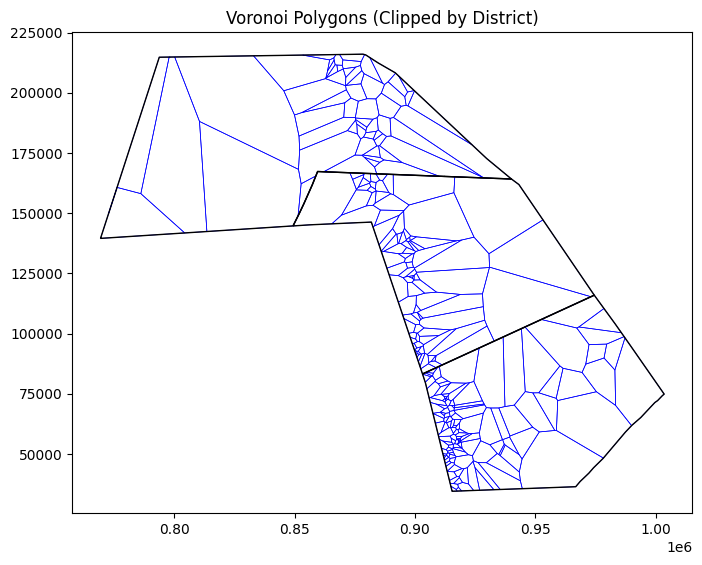

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# 7. SAVE AND DOWNLOAD
voronoi_gdf = gpd.GeoDataFrame(results, crs=districts.crs)
output_name = "somalia_district_voronoi.geojson"
voronoi_gdf.to_file(output_name, driver='GeoJSON')

print(f"Finished! Created {len(voronoi_gdf)} Voronoi cells.")

# Plotting for visual confirmation
fig, ax = plt.subplots(figsize=(8, 8))
voronoi_gdf.boundary.plot(ax=ax, linewidth=0.5, color='blue')
districts.boundary.plot(ax=ax, linewidth=1, color='black')
plt.title("Voronoi Polygons (Clipped by District)")
plt.show()

# Trigger the download to your computer
files.download(output_name)